# Compare HSA Boundary Versions: v6, v7, v8

This notebook compares the three HSA boundary bundles produced by `HSA_FINAL.ipynb`:

| Version | Algorithm | Anchors (INF footprint) |
|---------|-----------|------------------------|
| v6 | Greedy only | 17 |
| v7 | + Anchor upgrade / major-orphan promotion | 19 |
| v8 | v7 + satellite bubble boundaries | 19 |

**Sections:**
1. Load and summarize all three boundary files
2. Anchor set comparison: who changed?
3. Geometry comparison: area, overlap, compactness
4. Population allocation differences
5. Maps: side-by-side and v6 vs v7 diff
6. Spatial overlap (IoU per matched HSA)
7. Model coefficient stability
8. Summary


In [1]:
# ── Parameters ──────────────────────────────────────────────────────────────
import os
from pathlib import Path

NETWORK  = "INF"
HSA_MODE = "footprint"
OUT_DIR  = Path(os.environ.get("HSA_OUT_DIR", os.environ.get("PIPELINE_OUT_DIR", "out")))

VERSIONS = ["v6", "v7", "v8"]
UTM = "EPSG:32637"

boundary_paths = {v: OUT_DIR / f"{NETWORK}_{HSA_MODE}_hsas_{v}.geojson" for v in VERSIONS}
alloc_paths = {v: OUT_DIR / f"{NETWORK}_{HSA_MODE}_facility_hsa_assignments_{v}.csv" for v in VERSIONS}

print("Boundary files:")
for v, p in boundary_paths.items():
    print(f"  {v}: {'EXISTS' if p.exists() else 'MISSING'}  {p}")
print("\nAllocation tables:")
for v, p in alloc_paths.items():
    print(f"  {v}: {'EXISTS' if p.exists() else 'MISSING'}  {p}")


Boundary files:
  v6: EXISTS  out/INF_footprint_hsas_v6.geojson
  v7: EXISTS  out/INF_footprint_hsas_v7.geojson
  v8: EXISTS  out/INF_footprint_hsas_v8.geojson

Allocation tables:
  v6: EXISTS  out/INF_footprint_facility_hsa_assignments_v6.csv
  v7: EXISTS  out/INF_footprint_facility_hsa_assignments_v7.csv
  v8: EXISTS  out/INF_footprint_facility_hsa_assignments_v8.csv


## 1. Load and Summarize Boundary Files

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np

boundaries = {}
for v in VERSIONS:
    p = boundary_paths[v]
    if p.exists():
        gdf = gpd.read_file(p)
        boundaries[v] = gdf
        print(f"{v}: {len(gdf)} features, CRS={gdf.crs}, cols={list(gdf.columns)}")
    else:
        print(f"{v}: NOT FOUND — run HSA_FINAL.ipynb first")


v6: 17 features, CRS=EPSG:4326, cols=['AET_mm', 'DTR_C', 'FacilityName', 'P95_threshold_mm', 'PET_mm', 'P_mean_mm', 'P_total_mm', 'T_max_C', 'T_mean_C', 'T_min_C', 'VPD_kPa', 'deficit_mm', 'dewpoint_C', 'elevation_m', 'heavy_days_per_year', 'hot_days_per_year', 'lat', 'lon', 'runoff_mm', 'soil_moisture_mm', 'wetday_frac', 'wind_speed_ms', 'start_date', 'end_date', 'buffer_m', 'scale_m', 'extraction_date', 'climate_k', 'HealthFacility', 'healthfacility', 'total_diagnoses', 'healthfacilitytype', 'governorate', 'Total', 'initial_radius_km', 'urban_rural', 'service_radius_km', 'composite_score', 'coverage_norm', 'patient_norm', 'overlap_frac', 'climate_norm', 'progress_norm', 'distance_norm', 'hsa_population', 'hsa_pop_density_per_km2', 'patient_volume', 'network_type', 'optimization_mode', 'circle_geometry_wkt', 'geometry']
v7: 19 features, CRS=EPSG:4326, cols=['AET_mm', 'DTR_C', 'FacilityName', 'P95_threshold_mm', 'PET_mm', 'P_mean_mm', 'P_total_mm', 'T_max_C', 'T_mean_C', 'T_min_C', 'VP

In [3]:
def get_anchor_col(gdf):
    for c in ["anchor_name", "FacilityName", "HealthFacility", "healthfacility",
              "facility_id", "HSA_name", "name", "id"]:
        if c in gdf.columns:
            return c
    return gdf.columns[0]

rows = []
for v, gdf in boundaries.items():
    anchor_col = get_anchor_col(gdf)
    area_col = next((c for c in ["area_km2", "area"] if c in gdf.columns), None)
    pop_col  = next((c for c in ["hsa_population", "allocated_population", "population", "pop"]
                     if c in gdf.columns), None)
    mean_area = round(gdf.to_crs("EPSG:32637").geometry.area.mean() / 1e6, 0)
    rows.append({
        "Version": v,
        "Anchors": len(gdf),
        "Mean area (km^2)": mean_area,
        "Total pop (M)": round(gdf[pop_col].sum() / 1e6, 2) if pop_col else "N/A",
    })
print(pd.DataFrame(rows).to_string(index=False))


Version  Anchors  Mean area (km^2)  Total pop (M)
     v6       17             142.0          11.28
     v7       19             129.0          10.34
     v8       19             137.0          10.34


## 2. Anchor Set Comparison

In [4]:
anchor_sets = {}
for v, gdf in boundaries.items():
    col = get_anchor_col(gdf)
    anchor_sets[v] = set(gdf[col].astype(str))

if "v6" in anchor_sets and "v7" in anchor_sets:
    added_v7   = anchor_sets["v7"] - anchor_sets["v6"]
    removed_v7 = anchor_sets["v6"] - anchor_sets["v7"]
    print("=== v6 to v7 Changes ===")
    print(f"  Added   ({len(added_v7)}): {sorted(added_v7)}")
    print(f"  Removed ({len(removed_v7)}): {sorted(removed_v7)}")

if "v7" in anchor_sets and "v8" in anchor_sets:
    diff_v8 = anchor_sets["v8"] ^ anchor_sets["v7"]
    if diff_v8:
        print(f"\n=== v7 to v8: {len(diff_v8)} changes ===")
        print(f"  Changed: {sorted(diff_v8)}")
    else:
        print("\nv7 and v8 have identical anchor sets")


=== v6 to v7 Changes ===
  Added   (4): ['Al Hussain New Salt Hospital', 'Maan Hospital', 'Queen Rania Hospital', 'Tafilah Governmental Hospital']
  Removed (2): ['Al-Salaihy Primary Center', 'Bsaira Comprehensive Center']

v7 and v8 have identical anchor sets


In [5]:
# Full membership matrix
all_anchors = sorted(set().union(*anchor_sets.values()))
membership = pd.DataFrame(index=all_anchors)
for v in VERSIONS:
    if v in anchor_sets:
        membership[v] = ["Y" if a in anchor_sets[v] else "-" for a in all_anchors]
print(membership.to_string())


                                             v6 v7 v8
AL-Nadeem Hospital                            Y  Y  Y
AL-Ramtha Hospital                            Y  Y  Y
AL-Shuneh Hospital                            Y  Y  Y
AL-Zarqa Hospital                             Y  Y  Y
Al Hussain New Salt Hospital                  -  Y  Y
Al-Basheer Hospital                           Y  Y  Y
Al-Karak Hospital                             Y  Y  Y
Al-Mafraq Gynecology and Pediatrics Hospital  Y  Y  Y
Al-Salaihy Primary Center                     Y  -  -
Al-Yarmouk Hospital                           Y  Y  Y
Bsaira Comprehensive Center                   Y  -  -
Dr. Jamel Al-Totanji Hospital                 Y  Y  Y
Jadaa Primary Center                          Y  Y  Y
Jarash Hospital                               Y  Y  Y
Khazzan Primary Center                        Y  Y  Y
Maan Hospital                                 -  Y  Y
Mabroukeh Primary Center                      Y  Y  Y
Prince Hashem Primary Center

## 3. Geometry Comparison

In [6]:
import warnings
warnings.filterwarnings("ignore")
from shapely.ops import unary_union

stats_rows = []
for v, gdf in boundaries.items():
    g = gdf.to_crs(UTM).copy()
    areas = g.geometry.area / 1e6
    perims = g.geometry.length
    compactness = (4 * np.pi * g.geometry.area) / (perims ** 2)
    union_area = unary_union(g.geometry).area / 1e6
    raw_area = areas.sum()
    overlap_pct = (raw_area - union_area) / union_area * 100
    stats_rows.append({
        "Version": v,
        "N anchors": len(g),
        "Mean area (km^2)": round(areas.mean(), 0),
        "Covered (km^2)": round(union_area, 0),
        "Overlap (%)": round(overlap_pct, 1),
        "Compactness": round(compactness.mean(), 3),
    })

print(pd.DataFrame(stats_rows).set_index("Version").to_string())


         N anchors  Mean area (km^2)  Covered (km^2)  Overlap (%)  Compactness
Version                                                                       
v6              17             142.0          2031.0         18.5        0.078
v7              19             129.0          2086.0         17.7        0.089
v8              19             137.0          2120.0         23.1        0.084


In [7]:
# Per-anchor area changes v6->v7 for common anchors
if "v6" in boundaries and "v7" in boundaries:
    col6 = get_anchor_col(boundaries["v6"])
    col7 = get_anchor_col(boundaries["v7"])
    g6 = boundaries["v6"].to_crs(UTM).copy()
    g7 = boundaries["v7"].to_crs(UTM).copy()
    g6["area_km2"] = g6.geometry.area / 1e6
    g7["area_km2"] = g7.geometry.area / 1e6

    common = anchor_sets["v6"] & anchor_sets["v7"]
    area_rows = []
    for anchor in sorted(common):
        a6 = g6.loc[g6[col6] == anchor, "area_km2"].values
        a7 = g7.loc[g7[col7] == anchor, "area_km2"].values
        if len(a6) > 0 and len(a7) > 0:
            area_rows.append({"Anchor": anchor, "v6 (km^2)": round(a6[0], 1),
                               "v7 (km^2)": round(a7[0], 1), "Delta": round(a7[0]-a6[0], 1)})

    if area_rows:
        df_area = pd.DataFrame(area_rows).sort_values("Delta")
        print(df_area.to_string(index=False))
    else:
        print(f"No common anchors matched between v6 and v7 (anchor column: '{col6}').")
        print(f"Common set: {sorted(common)[:5]} ...")


                                      Anchor  v6 (km^2)  v7 (km^2)  Delta
                          AL-Nadeem Hospital      160.7      160.7    0.0
                          AL-Ramtha Hospital      166.1      166.1    0.0
                          AL-Shuneh Hospital       83.0       83.0    0.0
                           AL-Zarqa Hospital      149.0      149.0    0.0
                         Al-Basheer Hospital      373.5      373.5    0.0
                           Al-Karak Hospital       85.3       85.3    0.0
Al-Mafraq Gynecology and Pediatrics Hospital      145.7      145.7    0.0
                         Al-Yarmouk Hospital      140.8      140.8    0.0
               Dr. Jamel Al-Totanji Hospital      164.9      164.9    0.0
                        Jadaa Primary Center       30.9       30.9    0.0
                             Jarash Hospital      128.9      128.9    0.0
                      Khazzan Primary Center       50.4       50.4    0.0
                   Mabroukeh Primary C

## 4. Population Allocation Differences

In [8]:
allocs = {}
for v in VERSIONS:
    p = alloc_paths[v]
    if p.exists():
        allocs[v] = pd.read_csv(p)
        print(f"{v}: {len(allocs[v])} facilities")
    else:
        print(f"{v}: allocation table not found")


v6: 188 facilities
v7: 188 facilities
v8: 188 facilities


In [9]:
# Facility reassignments v6->v7
if "v6" in allocs and "v7" in allocs:
    a6 = allocs["v6"][["facility_id","primary_hsa"]].rename(columns={"primary_hsa":"hsa_v6"})
    a7 = allocs["v7"][["facility_id","primary_hsa"]].rename(columns={"primary_hsa":"hsa_v7"})
    merged = a6.merge(a7, on="facility_id", how="inner")
    changed = merged[merged["hsa_v6"] != merged["hsa_v7"]]
    print(f"Facilities with different primary HSA (v6 -> v7): {len(changed)}/{len(merged)} ({len(changed)/len(merged)*100:.1f}%)")
    if len(changed) > 0:
        print(changed.to_string(index=False))


Facilities with different primary HSA (v6 -> v7): 25/188 (13.3%)
                          facility_id                      hsa_v6                        hsa_v7
         Al Hussain New Salt Hospital   Al-Salaihy Primary Center  Al Hussain New Salt Hospital
Eskan Abu-Nsseir Al-Shamel Al-Tadribi   Al-Salaihy Primary Center  Al Hussain New Salt Hospital
         Swaileh Comprehensive Center   Al-Salaihy Primary Center  Al Hussain New Salt Hospital
                        Maan Hospital                         NaN                 Maan Hospital
              Prince Hussein Hospital   Al-Salaihy Primary Center  Al Hussain New Salt Hospital
             Um Nowara Primary Center          AL-Shuneh Hospital  Al Hussain New Salt Hospital
                 Queen Rania Hospital                         NaN          Queen Rania Hospital
        Tafilah Governmental Hospital Bsaira Comprehensive Center Tafilah Governmental Hospital
    Ain Al-Basha Comprehensive Center   Al-Salaihy Primary Center  Al H

In [10]:
# Case distribution by version
for v, df in allocs.items():
    if "assignment_case" in df.columns:
        print(f"\nVersion {v}:")
        print(df["assignment_case"].value_counts().to_string())
    elif "excluded" in df.columns:
        print(f"\nVersion {v}: {df['excluded'].sum()} excluded facilities")



Version v6:
assignment_case
Case 1: Inside 1 HSA                     153
Case 3: Inside 2+ HSAs (proportional)     23
Case 2: Outside all HSAs (nearest)         7
EXCLUDED: Requires anchor promotion        5

Version v7:
assignment_case
Case 1: Inside 1 HSA                     155
Case 3: Inside 2+ HSAs (proportional)     23
Case 2: Outside all HSAs (nearest)         9
EXCLUDED: Requires anchor promotion        1

Version v8:
assignment_case
Case 1: Inside 1 HSA                     155
Case 3: Inside 2+ HSAs (proportional)     23
Case 2: Outside all HSAs (nearest)         9
EXCLUDED: Requires anchor promotion        1


## 5. Maps

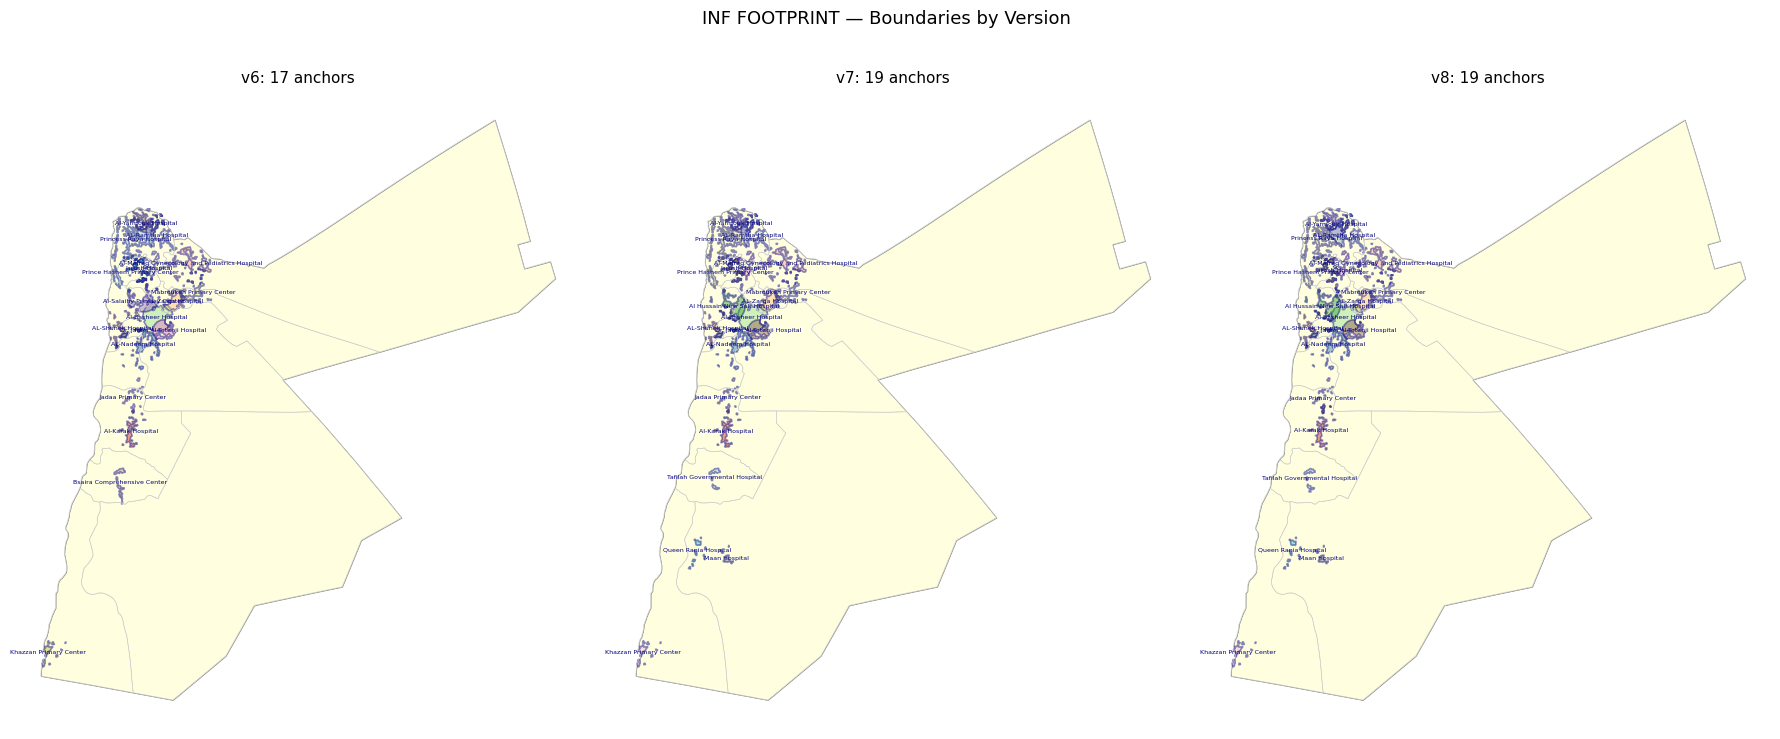

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

jordan_bnd = Path("data/jordan_boundary.gpkg")
jordan_gov = Path("data/jordan_governorates.gpkg")

if boundaries:
    n = len(boundaries)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 8))
    if n == 1:
        axes = [axes]

    for ax, (v, gdf) in zip(axes, boundaries.items()):
        if jordan_bnd.exists():
            gpd.read_file(jordan_bnd).to_crs("EPSG:4326").plot(ax=ax, color="lightyellow", edgecolor="gray", linewidth=0.5)
        if jordan_gov.exists():
            gpd.read_file(jordan_gov).to_crs("EPSG:4326").boundary.plot(ax=ax, color="#cccccc", linewidth=0.4)

        gdf.to_crs("EPSG:4326").plot(ax=ax, alpha=0.45, edgecolor="navy", linewidth=1.2,
                                      column=get_anchor_col(gdf), legend=False, cmap="tab20")
        col = get_anchor_col(gdf)
        for _, row in gdf.to_crs("EPSG:4326").iterrows():
            cx = row.geometry.centroid.x
            cy = row.geometry.centroid.y
            ax.text(cx, cy, str(row[col]).replace("_"," "), fontsize=4.5,
                    ha="center", va="center", color="navy")

        ax.set_title(f"{v}: {len(gdf)} anchors", fontsize=11)
        ax.set_axis_off()

    plt.suptitle(f"{NETWORK} {HSA_MODE.upper()} — Boundaries by Version", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{NETWORK}_{HSA_MODE}_boundary_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


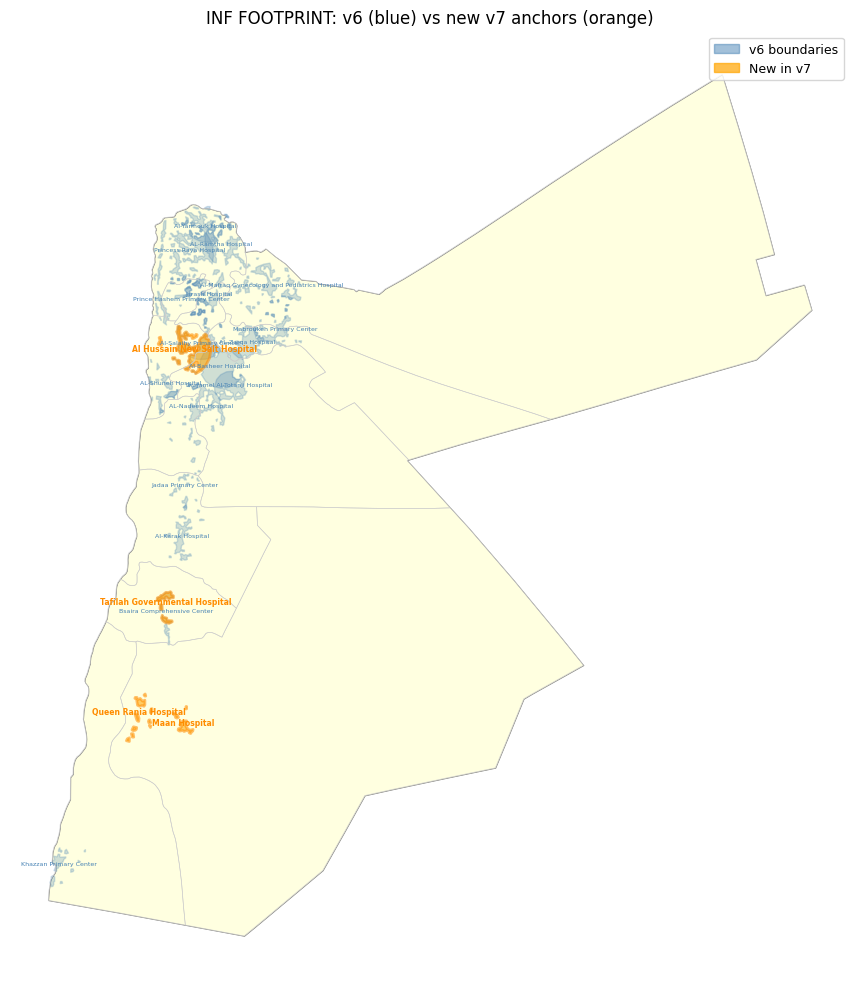

In [12]:
# Highlight v7 additions on v6 base
if "v6" in boundaries and "v7" in boundaries and "added_v7" in dir():
    col6 = get_anchor_col(boundaries["v6"])
    col7 = get_anchor_col(boundaries["v7"])
    fig, ax = plt.subplots(figsize=(9, 10))

    if jordan_bnd.exists():
        gpd.read_file(jordan_bnd).to_crs("EPSG:4326").plot(ax=ax, color="lightyellow", edgecolor="gray", linewidth=0.5)
    if jordan_gov.exists():
        gpd.read_file(jordan_gov).to_crs("EPSG:4326").boundary.plot(ax=ax, color="#cccccc", linewidth=0.4)

    boundaries["v6"].to_crs("EPSG:4326").plot(ax=ax, alpha=0.25, edgecolor="steelblue", linewidth=1.0, color="steelblue")

    v7_only = boundaries["v7"][boundaries["v7"][col7].isin(added_v7)]
    if len(v7_only) > 0:
        v7_only.to_crs("EPSG:4326").plot(ax=ax, alpha=0.55, edgecolor="darkorange", linewidth=2.0, color="orange")

    for _, row in boundaries["v6"].to_crs("EPSG:4326").iterrows():
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(cx, cy, str(row[col6]).replace("_"," "), fontsize=4.5, ha="center", color="steelblue")
    for _, row in v7_only.to_crs("EPSG:4326").iterrows():
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(cx, cy, str(row[col7]).replace("_"," "), fontsize=5.5, ha="center", color="darkorange", fontweight="bold")

    ax.legend(handles=[
        mpatches.Patch(color="steelblue", alpha=0.5, label="v6 boundaries"),
        mpatches.Patch(color="orange", alpha=0.7, label="New in v7"),
    ], fontsize=9, loc="upper right")
    ax.set_title(f"{NETWORK} {HSA_MODE.upper()}: v6 (blue) vs new v7 anchors (orange)", fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{NETWORK}_{HSA_MODE}_v6_v7_diff.png", dpi=150, bbox_inches="tight")
    plt.show()


## 6. Spatial Overlap (IoU per Matched HSA)

In [13]:
if "v6" in boundaries and "v7" in boundaries:
    col6 = get_anchor_col(boundaries["v6"])
    col7 = get_anchor_col(boundaries["v7"])
    g6 = boundaries["v6"].to_crs(UTM)
    g7 = boundaries["v7"].to_crs(UTM)

    iou_rows = []
    for anchor in sorted(anchor_sets["v6"] & anchor_sets["v7"]):
        rows6 = g6[g6[col6] == anchor]
        rows7 = g7[g7[col7] == anchor]
        if rows6.empty or rows7.empty:
            continue
        geom6 = rows6.geometry.iloc[0]
        geom7 = rows7.geometry.iloc[0]
        inter = geom6.intersection(geom7).area
        union = geom6.union(geom7).area
        iou = inter / union if union > 0 else 0
        iou_rows.append({"Anchor": anchor, "IoU": round(iou, 3),
                          "Area_v6": round(geom6.area/1e6, 1), "Area_v7": round(geom7.area/1e6, 1)})

    df_iou = pd.DataFrame(iou_rows).sort_values("IoU")
    print(df_iou.to_string(index=False))
    print(f"\nMean IoU: {df_iou['IoU'].mean():.3f}")
    print(f"Min IoU:  {df_iou['IoU'].min():.3f} ({df_iou.loc[df_iou['IoU'].idxmin(),'Anchor']})")


                                      Anchor  IoU  Area_v6  Area_v7
                          AL-Nadeem Hospital  1.0    160.7    160.7
                          AL-Ramtha Hospital  1.0    166.1    166.1
                          AL-Shuneh Hospital  1.0     83.0     83.0
                           AL-Zarqa Hospital  1.0    149.0    149.0
                         Al-Basheer Hospital  1.0    373.5    373.5
                           Al-Karak Hospital  1.0     85.3     85.3
Al-Mafraq Gynecology and Pediatrics Hospital  1.0    145.7    145.7
                         Al-Yarmouk Hospital  1.0    140.8    140.8
               Dr. Jamel Al-Totanji Hospital  1.0    164.9    164.9
                        Jadaa Primary Center  1.0     30.9     30.9
                             Jarash Hospital  1.0    128.9    128.9
                      Khazzan Primary Center  1.0     50.4     50.4
                   Mabroukeh Primary Center   1.0     98.4     98.4
               Prince Hashem Primary Center   1.

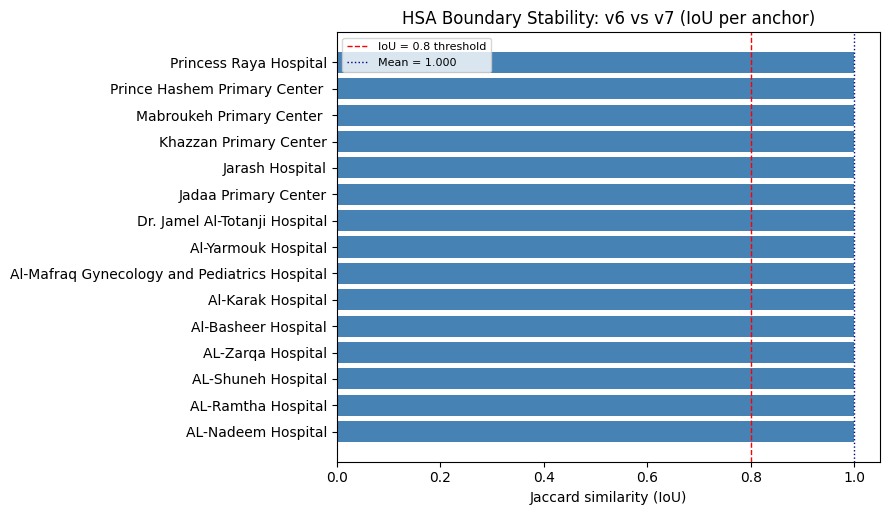

In [14]:
# IoU bar chart
if "df_iou" in dir() and len(df_iou) > 0:
    fig, ax = plt.subplots(figsize=(9, max(4, len(df_iou)*0.35)))
    colors = ["#e74c3c" if v < 0.8 else "steelblue" for v in df_iou["IoU"]]
    ax.barh(df_iou["Anchor"].str.replace("_"," "), df_iou["IoU"], color=colors)
    ax.axvline(0.8, color="red", linewidth=1, linestyle="--", label="IoU = 0.8 threshold")
    ax.axvline(df_iou["IoU"].mean(), color="navy", linewidth=1, linestyle=":", label=f"Mean = {df_iou['IoU'].mean():.3f}")
    ax.set_xlabel("Jaccard similarity (IoU)")
    ax.set_title("HSA Boundary Stability: v6 vs v7 (IoU per anchor)")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1.05)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{NETWORK}_{HSA_MODE}_iou_v6_v7.png", dpi=150, bbox_inches="tight")
    plt.show()


## 7. Model Coefficient Stability

Run `run_climate_models_daily.ipynb` for each boundary version and export
cumulative RR CSVs to `out/dlnm/{version}/cumulative_rr_precip.csv`.
Then re-run this cell to compare.


In [15]:
coef_data = {}
for v in VERSIONS:
    p = OUT_DIR / "dlnm" / v / "cumulative_rr_precip.csv"
    if p.exists():
        coef_data[v] = pd.read_csv(p)
        print(f"Loaded {v}: {p}")
    else:
        print(f"Not found ({v}): {p}")

if len(coef_data) >= 2:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = {"v6": "steelblue", "v7": "darkorange", "v8": "seagreen"}
    for v, df in coef_data.items():
        if "precip_value" in df.columns and "cumRR" in df.columns:
            ax.plot(df["precip_value"], df["cumRR"], label=f"{v}",
                    color=colors.get(v), linewidth=2)
            if "cumRR_lo" in df.columns:
                ax.fill_between(df["precip_value"], df["cumRR_lo"], df["cumRR_hi"],
                                alpha=0.15, color=colors.get(v))
    ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Daily precipitation (mm)")
    ax.set_ylabel("Cumulative RR (14-day)")
    ax.set_title("DLNM Cumulative RR Stability Across Boundary Versions")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "dlnm_rr_boundary_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


Not found (v6): out/dlnm/v6/cumulative_rr_precip.csv
Not found (v7): out/dlnm/v7/cumulative_rr_precip.csv
Not found (v8): out/dlnm/v8/cumulative_rr_precip.csv


## 8. Summary Table

In [16]:
print("=" * 65)
print(f"COMPARISON SUMMARY: {NETWORK} {HSA_MODE.upper()}")
print("=" * 65)
if stats_rows:
    print("\nGeometry:")
    print(pd.DataFrame(stats_rows).set_index("Version").to_string())
if "v6" in anchor_sets and "v7" in anchor_sets:
    print(f"\nv6 -> v7: added {sorted(added_v7)}, removed {sorted(removed_v7)}")


COMPARISON SUMMARY: INF FOOTPRINT

Geometry:
         N anchors  Mean area (km^2)  Covered (km^2)  Overlap (%)  Compactness
Version                                                                       
v6              17             142.0          2031.0         18.5        0.078
v7              19             129.0          2086.0         17.7        0.089
v8              19             137.0          2120.0         23.1        0.084

v6 -> v7: added ['Al Hussain New Salt Hospital', 'Maan Hospital', 'Queen Rania Hospital', 'Tafilah Governmental Hospital'], removed ['Al-Salaihy Primary Center', 'Bsaira Comprehensive Center']


In [17]:
# AUTO_NOTEBOOK_SUMMARY_V1
from pathlib import Path
from datetime import datetime
import os
import json

NOTEBOOK_NAME = "compare_delineations"
NETWORK  = globals().get('NETWORK',  os.environ.get('NETWORK',  'INF'))
HSA_MODE = globals().get('HSA_MODE', os.environ.get('HSA_MODE', 'footprint'))

suffix = f"{NETWORK}_{HSA_MODE}" if HSA_MODE else f"{NETWORK}"

out_root = Path(globals().get('OUT_DIR', os.environ.get('HSA_OUT_DIR', os.environ.get('PIPELINE_OUT_DIR', "out"))))
summary_dir = out_root / 'textresults'
summary_dir.mkdir(parents=True, exist_ok=True)
versions_tag = "_".join(globals().get('VERSIONS', ['v6', 'v7', 'v8']))
summary_path = summary_dir / f"{NOTEBOOK_NAME}_{suffix}_{versions_tag}_results.md"

files = [p for p in out_root.rglob('*') if p.is_file() and p.suffix.lower() in {'.csv', '.json', '.md', '.txt', '.png', '.pdf', '.geojson', '.parquet'}]
files.sort(key=lambda p: p.stat().st_mtime, reverse=True)
important = files[:120]

NL = "\n"

blocks = []
blocks.append(f"# Notebook Results: {NOTEBOOK_NAME}")

meta = [
    f"- Generated: {datetime.now().isoformat(timespec='seconds')}",
    f"- Network: {NETWORK}",
    f"- HSA mode: {HSA_MODE}",
    f"- Versions compared: {versions_tag}",
]
blocks.append(NL.join(meta))

file_lines = ['## Important Output Files', '']
for p in important:
    file_lines.append(f"- `{p}`")
blocks.append(NL.join(file_lines))

nb_path = Path(f"{NOTEBOOK_NAME}.ipynb")
if nb_path.exists():
    try:
        nb_data = json.loads(nb_path.read_text())
        blocks.append('## Displayed Cell Outputs')

        for idx, cell in enumerate(nb_data.get('cells', []), start=1):
            if cell.get('cell_type') != 'code':
                continue
            outputs = cell.get('outputs', []) or []
            if not outputs:
                continue

            blocks.append(f"### Cell {idx}")

            for out in outputs:
                otype = out.get('output_type')

                if otype == 'stream':
                    text = ''.join(out.get('text', [])) if isinstance(out.get('text', []), list) else str(out.get('text', ''))
                    text = text.rstrip()
                    if text:
                        blocks.append("```text" + NL + text + NL + "```")

                elif otype in ('execute_result', 'display_data'):
                    data = out.get('data', {})
                    if 'text/markdown' in data:
                        md = ''.join(data['text/markdown']) if isinstance(data['text/markdown'], list) else str(data['text/markdown'])
                        md = md.rstrip()
                        if md:
                            blocks.append(md)
                    elif 'text/plain' in data:
                        txt = ''.join(data['text/plain']) if isinstance(data['text/plain'], list) else str(data['text/plain'])
                        txt = txt.rstrip()
                        if txt:
                            blocks.append("```text" + NL + txt + NL + "```")
                    elif 'text/html' in data:
                        html = ''.join(data['text/html']) if isinstance(data['text/html'], list) else str(data['text/html'])
                        html = html.rstrip()
                        if html:
                            blocks.append("```html" + NL + html + NL + "```")
                    elif 'image/png' in data or 'image/jpeg' in data:
                        blocks.append('_[Image output omitted in text summary]_')

                elif otype == 'error':
                    tb = out.get('traceback', []) or []
                    if tb:
                        err = NL.join(str(t) for t in tb)
                    else:
                        err = f"{out.get('ename', 'Error')}: {out.get('evalue', '')}"
                    blocks.append("```text" + NL + err + NL + "```")

    except Exception as e:
        blocks.append('## Displayed Cell Outputs')
        blocks.append(f"Could not parse notebook outputs: {e}")

summary = (NL + NL).join(b for b in blocks if b and str(b).strip()) + NL
summary_path.write_text(summary)
print(f"Saved notebook summary: {summary_path}")


Saved notebook summary: out/textresults/compare_delineations_INF_footprint_v6_v7_v8_results.md
